### kNN

In [1]:
import pandas as pd

In [4]:
# 데이터 불러오기
train = pd.read_csv("../Data/basketball_train.csv")
test = pd.read_csv("../Data/basketball_test.csv")

In [5]:
# 전체 개수 확인
print(train.shape)
print(test.shape)

(80, 5)
(20, 5)


In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  80 non-null     str    
 1   Pos     80 non-null     str    
 2   3P      80 non-null     float64
 3   TRB     80 non-null     float64
 4   BLK     80 non-null     float64
dtypes: float64(3), str(2)
memory usage: 3.3 KB


In [7]:
test.info() # 20개 object, 나머지는 숫자

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  20 non-null     str    
 1   Pos     20 non-null     str    
 2   3P      20 non-null     float64
 3   TRB     20 non-null     float64
 4   BLK     20 non-null     float64
dtypes: float64(3), str(2)
memory usage: 932.0 bytes


#### 최적의 k 찾기와 교차 범증(Cross Validation)

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

In [11]:
# 최적의 k를 찾기 위햐 교차 검증을 수행할 k의 범위를 3부터 학습데이터의 절반까지 지정
max_k_range = train.shape[0] // 2 # 몫을 구할 때 // 기호 사용

In [12]:
# 최적의 k를 찾기 위한 범위 확인
k_list = [i for i in range(3, max_k_range,2)]
k_list

[3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39]

In [13]:
train_data = train[['3P', 'BLK', "TRB"]]
train_target = train['Pos']

In [22]:
# 교차 검증 (10 fold)을 각 k를 대상으로 수행해 검증결과를 저장
cross_validation_scores = []
for k in k_list:
   knn = KNeighborsClassifier(n_neighbors=k)
   scores = cross_val_score(
      knn,
      train_data,
      train_target,
      cv=10, # cross validation
      scoring='accuracy'
   )
   print(k, ";", scores)
   cross_validation_scores.append(scores.mean()
                  )

3 ; [0.875 0.875 0.875 0.875 0.875 0.875 0.75  1.    1.    0.75 ]
5 ; [0.875 0.75  0.875 0.875 1.    1.    0.75  1.    1.    0.875]
7 ; [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
9 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
11 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
13 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
15 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
17 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
19 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
21 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
23 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
25 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
27 ; [0.875 0.625 0.875 0.875 1.    1.    0.75  1.    1.    0.875]
29 ; [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]
31 ; [0.875 0.625 0.875 0.875 1.    0.875 0.75  1.    1.    0.875]

In [23]:
print(cross_val_score)

<function cross_val_score at 0x10f2a25c0>


Text(0, 0.5, 'Accurary')

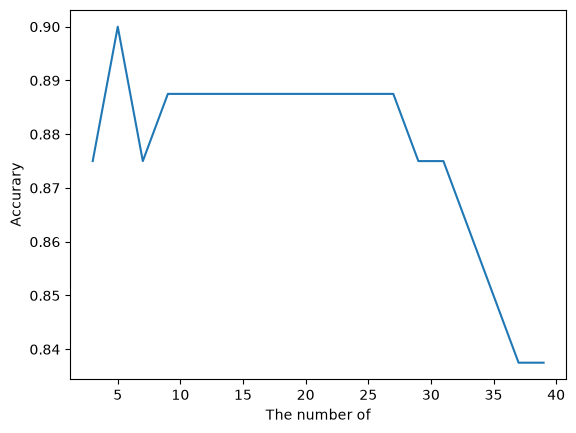

In [25]:
# k의 정확도 시각화
plt.plot(
   k_list,
   cross_validation_scores
)
plt.xlabel("The number of")
plt.ylabel("Accurary")

In [26]:
# 가장 예측율이 높은 k를 선점
k_list[cross_validation_scores.index(max(cross_validation_scores))]

5

----
#### 2개의 특징으로 예측하기 (3점슛, 블로킹)

In [ ]:
# Model
knn = KNeighborsClassifier(n_neighbors=5)

In [27]:
# Feature
train_data = train[['3P','BLK']]

In [28]:
# Target
train_target = train["Pos"]

In [29]:
# 학습시키기
knn.fit(train_data,train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",39
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['C','SG']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [30]:
test_data = test[['3P', 'BLK']]
test_target = test["Pos"]

In [31]:
# 평가
print("Train :", knn.score(train_data, train_target))
print("Test :", knn.score(test_data, test_target))

Train : 0.925
Test : 0.85


----
#### 3개의 특징으로 예측하기 (3점슛, 블로킹, 리바운드)

In [32]:
# Feature
train_data = train[['3P', 'BLK', 'TRB']]

In [33]:
# Target
train_target = train['Pos']

In [34]:
# 학습시키기
knn.fit(train_data, train_target)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",39
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['C','SG']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [35]:
test_data = test[['3P', 'BLK', 'TRB']]
test_target = test['Pos']


In [36]:
# 평가
print("Train :", knn.score(train_data, train_target))
print("Test :", knn.score(test_data, test_target))

Train : 0.8625
Test : 0.65


----
#### 학습한 AI Model 사용해보기
어떤 선수의 점수가 아래와 같을 경우 포지션 추천하기
- 3P : 3.4
- BLK : 0.5
- TRB : 3.7

In [37]:
train_data

,3P,BLK,TRB
0,0.9,1.1,7.8
1,1.8,0.4,6.2
2,1.7,0.3,2.9
3,1.3,0.2,2.3
4,1.7,0.8,3.3
...,...,...,...
75,0.0,0.7,10.4
76,0.0,0.8,4.2
77,1.9,0.3,4.3
78,0.0,1.3,5.1


In [43]:
# 점수 입력
data = {
   '3P' : [3.4],
   'BLK' : [0.5],
   'TRB' : [3.7]
}
df = pd.DataFrame(data)
df

,3P,BLK,TRB
0,3.4,0.5,3.7


In [44]:
pred= knn.predict(df)
print("포지션 :", pred)

포지션 : ['SG']


#### Ai 저장하기

In [45]:
import joblib

In [46]:
joblib.dump(knn, "../Data/knn_basketball.h5")

['../Data/knn_basketball.h5']